In [1]:
import sys
print(sys.executable)

import os
print(os.getcwd())
print(os.path.exists('../datasets/train_data.csv'))
print(os.path.exists('../datasets/test_data.csv'))
print(os.path.exists('../datasets/final_lyrics_features_combined.csv'))

/Users/cho/Developer/LyricGeneration/venv/bin/python3.14
/Users/cho/Developer/LyricGeneration/src final project
True
True
True


In [2]:
import pandas as pd
import numpy as np
import torch
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW
from tqdm import tqdm  # For progress bars
from torch.utils.data import DataLoader, Dataset
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sacrebleu.metrics import BLEU
from sacrebleu import corpus_bleu
from nltk.translate.bleu_score import corpus_bleu
import nltk
import matplotlib.pyplot as plt
from rouge_score import rouge_scorer
from scipy.stats import pearsonr
from rhyme_loss import normalize_lyrics_for_rhyme, prepare_rhyme_supervision, compute_rhyme_loss

Set up Hugging Face Model

In [3]:
tokenizer = GPT2TokenizerFast.from_pretrained('gpt2')
model = GPT2LMHeadModel.from_pretrained('gpt2')
tokenizer.pad_token = tokenizer.eos_token
model.config.pad_token_id = tokenizer.eos_token_id
scaler = StandardScaler()
NUM_EPOCHS = 2
RHYME_LOSS_WEIGHT = 0.15
MAX_RHYME_POSITIONS = 16

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

In [4]:
if torch.cuda.is_available():
    print("CUDA GPU is available")
elif torch.backends.mps.is_available():
    print("MPS GPU is available")
else:
    print("GPU is not available")

MPS GPU is available


In [5]:
def create_input_sequences(df, numerical_columns, categorical_columns, lyrics_column):
    input_sequences = []
    for idx, row in df.iterrows():
        feature_string = ' '.join([f"<{col.upper()}: {row[col]:.2f}>" for col in numerical_columns] +
                                  [f"<{col.upper()}: {row[col]}>" for col in categorical_columns])

        input_sequence = f"{feature_string} <LYRICS>: {row[lyrics_column]}"
        input_sequences.append(input_sequence)
    return input_sequences

def apply_feature_weights(df, numerical_columns, feature_weights):
    for column in numerical_columns:
        if column in feature_weights:
            df[column] = df[column] * feature_weights[column]
    return df

feature_weights = {
    'TEMPO': 4.5,
    'VALENCE': 4.0,
    'POPULARITY': 4.0,
    'DANCEABILITY': 3.5,
    'ENERGY': 4.5,
    'LOUDNESS': 3.0,
    'ACOUSTICNESS': 3.5,
    'INSTRUMENTALNESS': 3.5,
    'LIVENESS': 3.0,
    'EXPLICIT': 2.5,
    'DURATION_MS': 1.0,
}

Prepare Train and Test Data

In [6]:
train_path = '../datasets/train_data.csv'
test_path = '../datasets/val_data.csv'

df = pd.read_csv('../datasets/final_lyrics_features_combined.csv')
df['explicit'] = df['explicit'].astype(int)
df.columns = df.columns.str.upper()

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
train_df.columns = train_df.columns.str.upper()
test_df.columns = test_df.columns.str.upper()

numerical_columns = [
    'DURATION_MS', 'POPULARITY', 'DANCEABILITY', 'ENERGY', 'LOUDNESS',
    'ACOUSTICNESS', 'INSTRUMENTALNESS', 'LIVENESS', 'VALENCE', 'TEMPO', 'EXPLICIT'
]
categorical_columns = ['ARTIST', 'TRACK_GENRE']

combined_df = pd.concat([train_df, test_df], axis=0)

train_df = combined_df.iloc[:train_df.shape[0]].copy()
test_df = combined_df.iloc[train_df.shape[0]:].copy()

train_df = train_df.astype({col: float for col in numerical_columns})
test_df = test_df.astype({col: float for col in numerical_columns})

train_df['LYRICS'] = train_df['LYRICS'].fillna('').apply(normalize_lyrics_for_rhyme)
test_df['LYRICS'] = test_df['LYRICS'].fillna('').apply(normalize_lyrics_for_rhyme)

Scale Numeric Values

In [7]:
train_df.loc[:, numerical_columns] = scaler.fit_transform(train_df[numerical_columns])
test_df.loc[:, numerical_columns] = scaler.transform(test_df[numerical_columns])

Combine into one Sequence

In [8]:
train_df = apply_feature_weights(train_df, numerical_columns, feature_weights)
test_df = apply_feature_weights(test_df, numerical_columns, feature_weights)

train_input_sequences = create_input_sequences(train_df, numerical_columns, categorical_columns, 'LYRICS')
test_input_sequences = create_input_sequences(test_df, numerical_columns, categorical_columns, 'LYRICS')

In [9]:
train_encodings, train_rhyme_positions, train_rhyme_group_ids = prepare_rhyme_supervision(
    train_input_sequences,
    tokenizer,
    max_length=512,
    max_rhyme_positions=MAX_RHYME_POSITIONS,
)
test_encodings, test_rhyme_positions, test_rhyme_group_ids = prepare_rhyme_supervision(
    test_input_sequences,
    tokenizer,
    max_length=512,
    max_rhyme_positions=MAX_RHYME_POSITIONS,
)

class LyricsFeatureDataset(Dataset):
    def __init__(self, encodings, rhyme_positions, rhyme_group_ids):
        self.encodings = encodings
        self.rhyme_positions = rhyme_positions
        self.rhyme_group_ids = rhyme_group_ids

    def __getitem__(self, idx):
        item = {key: val[idx].clone().detach() for key, val in self.encodings.items()}
        item['rhyme_positions'] = self.rhyme_positions[idx].clone().detach()
        item['rhyme_group_ids'] = self.rhyme_group_ids[idx].clone().detach()
        return item

    def __len__(self):
        return len(self.encodings['input_ids'])

train_dataset = LyricsFeatureDataset(train_encodings, train_rhyme_positions, train_rhyme_group_ids)
test_dataset = LyricsFeatureDataset(test_encodings, test_rhyme_positions, test_rhyme_group_ids)

In [10]:
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

epochs = NUM_EPOCHS
num_epochs = epochs
#optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.01)  # can use for really high epoch models
optimizer = AdamW(model.parameters(), lr=5e-5)

total_steps = len(train_loader) * epochs
scheduler = get_linear_schedule_with_warmup(optimizer,
                                            num_warmup_steps=0,  # No warm-up
                                            num_training_steps=total_steps)
print(device)

cpu


## Training Loop

In [11]:
%%capture
nltk.download('punkt')

def calculate_rouge_scores(hypotheses, references):
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    scores = {'rouge1': [], 'rouge2': [], 'rougeL': []}

    for hyp, ref in zip(hypotheses, references):
        score = scorer.score(ref, hyp)
        scores['rouge1'].append(score['rouge1'].fmeasure)
        scores['rouge2'].append(score['rouge2'].fmeasure)
        scores['rougeL'].append(score['rougeL'].fmeasure)

    avg_scores = {key: sum(values) / len(values) for key, values in scores.items()}
    return avg_scores

train_losses, val_losses, val_bleu_scores, lr_rates, val_rouge_scores = [], [], [], [], []

[nltk_data] Downloading package punkt to /Users/cho/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [12]:
import warnings ## supress warnings

warnings.filterwarnings("ignore", message="Setting `pad_token_id` to `eos_token_id` for open-end generation.")
warnings.filterwarnings("ignore", message="A decoder-only architecture is being used, but right-padding was detected!")

In [13]:
## TRAINING STEP with score output
all_train_losses, all_lr_rates = [], []
all_train_rhyme_losses, all_val_rhyme_losses = [], []
all_rouge1_scores, all_rouge2_scores, all_rougeL_scores = [], [], []
all_avg_val_losses = [] 
training_time_per_epoch = [] 
all_val_bleu_scores = []

for epoch in range(epochs):
    model.train()
    train_losses, train_rhyme_losses, lr_rates = [], [], []

    for batch_idx, batch in enumerate(train_loader): 
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        rhyme_positions = batch['rhyme_positions'].to(device)
        rhyme_group_ids = batch['rhyme_group_ids'].to(device)

        model.zero_grad()
        outputs = model(
            input_ids,
            attention_mask=attention_mask,
            labels=input_ids,
            output_hidden_states=True,
        )
        lm_loss = outputs.loss
        rhyme_loss = compute_rhyme_loss(outputs.hidden_states[-1], rhyme_positions, rhyme_group_ids)
        loss = lm_loss + (RHYME_LOSS_WEIGHT * rhyme_loss)

        loss.backward()
        optimizer.step()
        scheduler.step()

        batch_loss = loss.item()
        batch_rhyme_loss = rhyme_loss.item()
        all_train_losses.append(batch_loss)
        all_train_rhyme_losses.append(batch_rhyme_loss)
        all_lr_rates.append(scheduler.get_last_lr()[0])

        train_losses.append(batch_loss)
        train_rhyme_losses.append(batch_rhyme_loss)
        lr_rates.append(scheduler.get_last_lr()[0])
        print(
            f"Epoch {epoch+1}/{epochs}, Batch {batch_idx}/{len(train_loader)}, "
            f"Train Loss: {batch_loss:.4f}, Rhyme Loss: {batch_rhyme_loss:.4f}"
        )

    model.eval()
    val_loss, val_rhyme_loss, hypotheses, references = 0, 0, [], []
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            rhyme_positions = batch['rhyme_positions'].to(device)
            rhyme_group_ids = batch['rhyme_group_ids'].to(device)

            outputs = model(
                input_ids,
                attention_mask=attention_mask,
                labels=input_ids,
                output_hidden_states=True,
            )
            batch_val_rhyme_loss = compute_rhyme_loss(outputs.hidden_states[-1], rhyme_positions, rhyme_group_ids)
            batch_val_loss = outputs.loss + (RHYME_LOSS_WEIGHT * batch_val_rhyme_loss)

            val_loss += batch_val_loss.item()
            val_rhyme_loss += batch_val_rhyme_loss.item()

            predictions = model.generate(input_ids, attention_mask=attention_mask, max_new_tokens=50)

            hyp_texts = [tokenizer.decode(g, skip_special_tokens=True) for g in predictions]
            ref_texts = [tokenizer.decode(g, skip_special_tokens=True) for g in input_ids]
            hypotheses.extend(hyp_texts)
            references.extend(ref_texts)

    avg_train_loss = np.mean(train_losses)
    avg_train_rhyme_loss = np.mean(train_rhyme_losses) if train_rhyme_losses else 0.0
    avg_val_loss = val_loss / len(test_loader)
    avg_val_rhyme_loss = val_rhyme_loss / len(test_loader)
    all_avg_val_losses.append(avg_val_loss)  
    all_val_rhyme_losses.append(avg_val_rhyme_loss)
    val_bleu = corpus_bleu([[ref.split()] for ref in references], [hyp.split() for hyp in hypotheses])
    all_val_bleu_scores.append(val_bleu)  
    
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    val_rouge_scores = {key: [] for key in ['rouge1', 'rouge2', 'rougeL']}
    for hyp, ref in zip(hypotheses, references):
        scores = scorer.score(ref, hyp)
        for key in val_rouge_scores.keys():
            val_rouge_scores[key].append(scores[key].fmeasure)
    avg_rouge_scores = {key: np.mean(val) for key, val in val_rouge_scores.items()}
    all_rouge1_scores.append(np.mean(val_rouge_scores['rouge1']))
    all_rouge2_scores.append(np.mean(val_rouge_scores['rouge2']))
    all_rougeL_scores.append(np.mean(val_rouge_scores['rougeL']))
    print(
        f"Epoch {epoch+1}, Train Loss: {avg_train_loss}, Train Rhyme Loss: {avg_train_rhyme_loss}, "
        f"Validation Loss: {avg_val_loss}, Validation Rhyme Loss: {avg_val_rhyme_loss}, "
        f"Validation BLEU: {val_bleu}, Validation ROUGE: {avg_rouge_scores}"
    )

model_save_path = './gpt2_lyrics_model_' + str(epochs) + '_epochs'
model.save_pretrained(model_save_path)

tokenizer_save_path = './gpt2_lyrics_tokenizer_' + str(epochs) + '_epochs'
tokenizer.save_pretrained(tokenizer_save_path)

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Epoch 1/2, Batch 0/132, Train Loss: 3.8373, Rhyme Loss: 4.0729
Epoch 1/2, Batch 1/132, Train Loss: 4.0279, Rhyme Loss: 3.6991
Epoch 1/2, Batch 2/132, Train Loss: 4.9086, Rhyme Loss: 7.1492
Epoch 1/2, Batch 3/132, Train Loss: 4.8264, Rhyme Loss: 6.3874
Epoch 1/2, Batch 4/132, Train Loss: 3.6013, Rhyme Loss: 4.5457
Epoch 1/2, Batch 5/132, Train Loss: 3.0749, Rhyme Loss: 3.5452
Epoch 1/2, Batch 6/132, Train Loss: 2.7380, Rhyme Loss: 2.9654
Epoch 1/2, Batch 7/132, Train Loss: 3.2988, Rhyme Loss: 4.5408
Epoch 1/2, Batch 8/132, Train Loss: 2.9987, Rhyme Loss: 3.2261
Epoch 1/2, Batch 9/132, Train Loss: 3.0549, Rhyme Loss: 4.2520
Epoch 1/2, Batch 10/132, Train Loss: 3.2757, Rhyme Loss: 2.9683
Epoch 1/2, Batch 11/132, Train Loss: 3.4692, Rhyme Loss: 4.7750
Epoch 1/2, Batch 12/132, Train Loss: 2.8042, Rhyme Loss: 4.5168
Epoch 1/2, Batch 13/132, Train Loss: 3.5111, Rhyme Loss: 3.6465
Epoch 1/2, Batch 14/132, Train Loss: 2.9129, Rhyme Loss: 4.0877
Epoch 1/2, Batch 15/132, Train Loss: 3.0487, Rhyme

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
Setting `pad_token_i

Epoch 1, Train Loss: 2.763322723634315, Train Rhyme Loss: 3.1719120569301373, Validation Loss: 2.4478698628289357, Validation Rhyme Loss: 3.2669985464641025, Validation BLEU: 0.8821105920392646, Validation ROUGE: {'rouge1': np.float64(0.9386253943300634), 'rouge2': np.float64(0.9384145674643891), 'rougeL': np.float64(0.9386253943300634)}
Epoch 2/2, Batch 0/132, Train Loss: 2.4240, Rhyme Loss: 2.5240
Epoch 2/2, Batch 1/132, Train Loss: 3.1239, Rhyme Loss: 3.4533
Epoch 2/2, Batch 2/132, Train Loss: 2.0655, Rhyme Loss: 2.5694
Epoch 2/2, Batch 3/132, Train Loss: 2.8632, Rhyme Loss: 4.3528
Epoch 2/2, Batch 4/132, Train Loss: 2.5675, Rhyme Loss: 2.7247
Epoch 2/2, Batch 5/132, Train Loss: 2.7189, Rhyme Loss: 2.8652
Epoch 2/2, Batch 6/132, Train Loss: 2.2242, Rhyme Loss: 2.4962
Epoch 2/2, Batch 7/132, Train Loss: 2.6566, Rhyme Loss: 1.9378
Epoch 2/2, Batch 8/132, Train Loss: 2.6532, Rhyme Loss: 3.4127
Epoch 2/2, Batch 9/132, Train Loss: 2.8207, Rhyme Loss: 2.0421
Epoch 2/2, Batch 10/132, Train

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
Setting `pad_token_i

Epoch 2, Train Loss: 2.414681399410421, Train Rhyme Loss: 2.638344782319936, Validation Loss: 2.3504229358264377, Validation Rhyme Loss: 2.7894288301467896, Validation BLEU: 0.8807706897755986, Validation ROUGE: {'rouge1': np.float64(0.9360203575557761), 'rouge2': np.float64(0.9357908101143146), 'rougeL': np.float64(0.9360203575557761)}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./gpt2_lyrics_tokenizer_2_epochs/tokenizer_config.json',
 './gpt2_lyrics_tokenizer_2_epochs/tokenizer.json')

In [15]:
model_save_path = './gpt2_lyrics_model_2_epochs'
tokenizer_save_path = './gpt2_lyrics_tokenizer_2_epochs'
model = GPT2LMHeadModel.from_pretrained(model_save_path)
tokenizer = GPT2TokenizerFast.from_pretrained(tokenizer_save_path)
device = torch.device("cpu")
model.to(device)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

#### Use the code blocks below to evaluate training, such as lyric generation and metric visualization

In [16]:
def generate_lyrics_with_features(model, tokenizer, features, device):
    """
    Generate lyrics based on structured features and a prompt.

    Args:
    - model: The trained GPT model.
    - tokenizer: The tokenizer used for the GPT model.
    - features: A dictionary containing the features and their values.
    - device: The device ('cuda' or 'cpu') to perform the computation on.

    Returns:
    - The generated lyrics as a string.
    """
    numerical_features = {k: v for k, v in features.items() if k in numerical_columns}
    categorical_features = {k: v for k, v in features.items() if k in categorical_columns}

    feature_string = ' '.join([f"<{key.upper()}: {value}>" for key, value in numerical_features.items()] +
                              [f"<{key.upper()}: {value}>" for key, value in categorical_features.items()])

    print("FEATURE STRING:")
    print(feature_string)
    print("FEATURE STRING:")

    input_sequence = f"{feature_string} <LYRICS>:"

    inputs = tokenizer.encode(input_sequence, return_tensors='pt').to(device)

    output_sequences = model.generate(
        input_ids=inputs,
        max_length=512,
        min_length=50,
        num_beams=5,
        no_repeat_ngram_size=2,
        early_stopping=True,
        temperature=0.9, 
        top_k=50,  
        top_p=0.92, 
    )

    lyrics = tokenizer.decode(output_sequences[0], skip_special_tokens=True)

    return lyrics


features = {
    'DURATION_MS': 0.9,
    'POPULARITY': 0.45,
    'DANCEABILITY': 1.28,
    'ENERGY': 0.49,
    'LOUDNESS': -0.18,
    'ACOUSTICNESS': 0.51,
    'INSTRUMENTALNESS': 0.12,
    'LIVENESS': 0.67,
    'VALENCE': 0.3,
    'TEMPO': -0.59,
    'EXPLICIT': -0.88,
    'ARTIST': 'Taylor Swift',  # Note: Ensure these match the format expected by your model
    'TRACK_GENRE': 'soul'  # Same note as above
}

result = {}
for key in features:
    if key in feature_weights and key not in ['ARTIST', 'TRACK_GENRE']:
        result[key] = feature_weights[key] * features[key]

generated_lyrics = generate_lyrics_with_features(model, tokenizer, result, device)
lyrics_index = generated_lyrics.find("<LYRICS>:")

final_output = generated_lyrics[lyrics_index + len("<LYRICS>:"):]
print("Generated Lyrics:\n")
print(final_output)


The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


FEATURE STRING:
<DURATION_MS: 0.9> <POPULARITY: 1.8> <DANCEABILITY: 4.48> <ENERGY: 2.205> <LOUDNESS: -0.54> <ACOUSTICNESS: 1.7850000000000001> <INSTRUMENTALNESS: 0.42> <LIVENESS: 2.0100000000000002> <VALENCE: 1.2> <TEMPO: -2.655> <EXPLICIT: -2.2>
FEATURE STRING:
Generated Lyrics:

 -1.88> </TRACK_GENRE: pop>


### Visualization

**Summary of Training Metrics**

In [17]:
def summarize_training_performance(all_train_losses, all_lr_rates, all_rouge1_scores, all_rouge2_scores, all_rougeL_scores, val_bleu, epochs):
    avg_train_loss = np.mean(all_train_losses)

    lowest_train_loss = min(all_train_losses)
    final_train_loss = all_train_losses[-1]

    initial_lr = all_lr_rates[0]
    final_lr = all_lr_rates[-1]

    avg_rouge1 = np.mean(all_rouge1_scores)
    avg_rouge2 = np.mean(all_rouge2_scores)
    avg_rougeL = np.mean(all_rougeL_scores)

    print(f"Training Summary Over {epochs} Epochs:")
    print(f"- Average Training Loss: {avg_train_loss:.4f}")
    print(f"- Lowest Training Loss: {lowest_train_loss:.4f}")
    print(f"- Final Training Loss: {final_train_loss:.4f}")
    print(f"- Learning Rate Started at {initial_lr} and Ended at {final_lr}")
    print(f"- Validation BLEU Score: {val_bleu:.4f}")
    print(f"- Average ROUGE-1 Score: {avg_rouge1:.4f}")
    print(f"- Average ROUGE-2 Score: {avg_rouge2:.4f}")
    print(f"- Average ROUGE-L Score: {avg_rougeL:.4f}")


summarize_training_performance(all_train_losses, all_lr_rates, all_rouge1_scores, all_rouge2_scores, all_rougeL_scores, val_bleu, epochs)


Training Summary Over 2 Epochs:
- Average Training Loss: 2.5890
- Lowest Training Loss: 1.4016
- Final Training Loss: 3.0727
- Learning Rate Started at 4.9810606060606065e-05 and Ended at 0.0
- Validation BLEU Score: 0.8808
- Average ROUGE-1 Score: 0.9373
- Average ROUGE-2 Score: 0.9371
- Average ROUGE-L Score: 0.9373


Training Loss Improvement: 19.92% over 2 epochs.
ROUGE-1 Score Improvement: -0.28%
ROUGE-2 Score Improvement: -0.28%
ROUGE-L Score Improvement: -0.28%
Validation BLEU Score by the end of training: 0.8808
Consider reviewing learning rate schedule. Improvements in loss may not correlate well with learning rate adjustments.


/Users/cho/Developer/LyricGeneration/venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/cho/Developer/LyricGeneration/venv/lib/python3.14/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


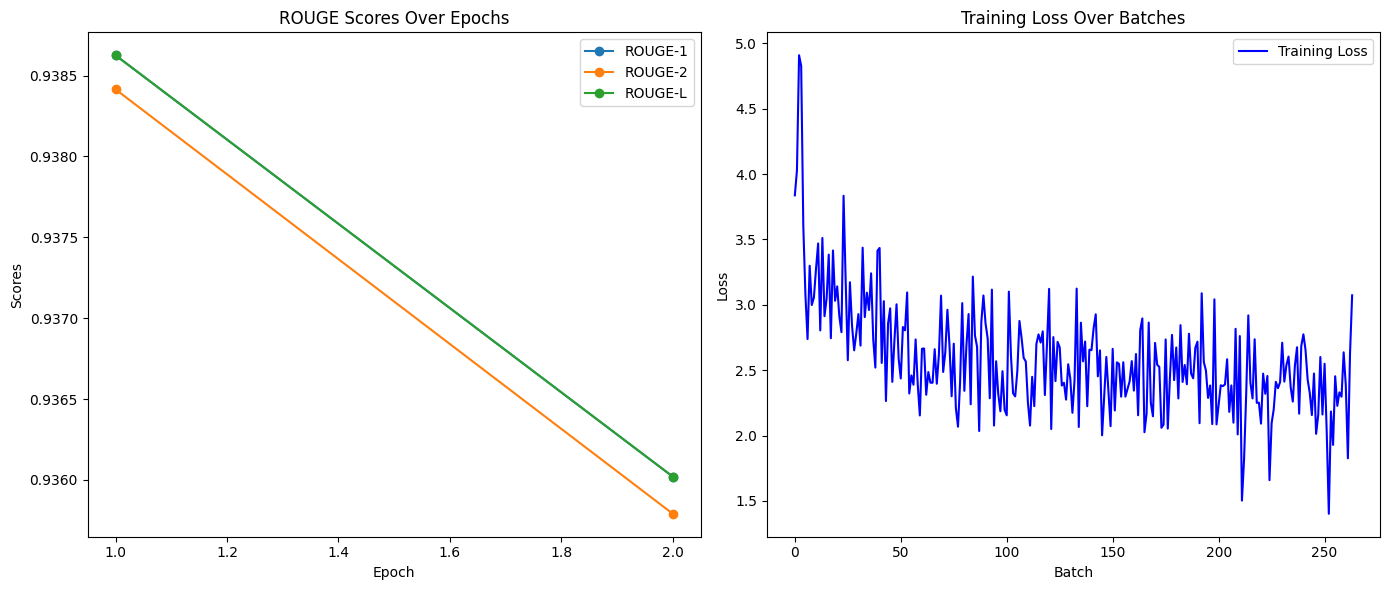

Modest improvement in ROUGE-1 may indicate the need for longer training or model adjustments.


In [18]:
def analyze_model_performance(all_train_losses, all_lr_rates, all_rouge1_scores, all_rouge2_scores, all_rougeL_scores, val_bleu, epochs):
    loss_improvement = (all_train_losses[0] - all_train_losses[-1]) / all_train_losses[0]
    print(f"Training Loss Improvement: {loss_improvement * 100:.2f}% over {epochs} epochs.")

    rouge1_improvement = (all_rouge1_scores[-1] - all_rouge1_scores[0]) / max(1e-5, all_rouge1_scores[0])
    rouge2_improvement = (all_rouge2_scores[-1] - all_rouge2_scores[0]) / max(1e-5, all_rouge2_scores[0])
    rougeL_improvement = (all_rougeL_scores[-1] - all_rougeL_scores[0]) / max(1e-5, all_rougeL_scores[0])

    print(f"ROUGE-1 Score Improvement: {rouge1_improvement * 100:.2f}%")
    print(f"ROUGE-2 Score Improvement: {rouge2_improvement * 100:.2f}%")
    print(f"ROUGE-L Score Improvement: {rougeL_improvement * 100:.2f}%")
    print(f"Validation BLEU Score by the end of training: {val_bleu:.4f}")

    if loss_improvement > 0 and np.mean(all_lr_rates[-(epochs//4):]) < np.mean(all_lr_rates[:epochs//4]):
        print("Decreasing learning rate correlates with improved loss, suggesting effective learning rate scheduling.")
    else:
        print("Consider reviewing learning rate schedule. Improvements in loss may not correlate well with learning rate adjustments.")

    epochs_range = range(1, epochs + 1)
    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, all_rouge1_scores, label='ROUGE-1', marker='o')
    plt.plot(epochs_range, all_rouge2_scores, label='ROUGE-2', marker='o')
    plt.plot(epochs_range, all_rougeL_scores, label='ROUGE-L', marker='o')
    plt.title('ROUGE Scores Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Scores')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(all_train_losses, label='Training Loss', color='blue')
    plt.title('Training Loss Over Batches')
    plt.xlabel('Batch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

    if rouge1_improvement > 0.1:
        print("Significant improvement in ROUGE-1 suggests good learning in capturing key information from the reference texts.")
    else:
        print("Modest improvement in ROUGE-1 may indicate the need for longer training or model adjustments.")

analyze_model_performance(all_train_losses, all_lr_rates, all_rouge1_scores, all_rouge2_scores, all_rougeL_scores, val_bleu, epochs)


In [20]:
def evaluate_advanced_metrics_fixed(all_train_losses, all_avg_val_losses, all_lr_rates, all_rouge1_scores, epochs, training_time_per_epoch):
    batches_per_epoch = len(all_train_losses) // epochs
    avg_train_losses_per_epoch = [np.mean(all_train_losses[i * batches_per_epoch:(i + 1) * batches_per_epoch]) for i in range(epochs)]
    rouge1_stability = np.std(all_rouge1_scores[-3:])  # Last 3 epochs
    print(f"ROUGE-1 Stability (last 3 epochs): {rouge1_stability:.4f}")

    if len(all_avg_val_losses) == len(avg_train_losses_per_epoch):
        overfitting_indicator = np.array(all_avg_val_losses) - np.array(avg_train_losses_per_epoch)
        overfit_indicator_avg_last_3 = np.mean(overfitting_indicator[-3:])
        print(f"Overfitting Indicator (avg. of last 3 epochs): {overfit_indicator_avg_last_3:.4f}")
    else:
        print("Mismatch in length between average validation losses and calculated average training losses per epoch.")

evaluate_advanced_metrics_fixed(
    all_train_losses=all_train_losses,
    all_avg_val_losses=all_avg_val_losses, 
    all_lr_rates=all_lr_rates,
    all_rouge1_scores=all_rouge1_scores,
    epochs=epochs,
    training_time_per_epoch=[3600] * epochs 
)


ROUGE-1 Stability (last 3 epochs): 0.0013
Overfitting Indicator (avg. of last 3 epochs): -0.1899


**Training Loss Visualzation**

In [19]:
batches_per_epoch = 132
total_batches = batches_per_epoch * epochs

plt.figure(figsize=(12, 6))
plt.plot(all_train_losses, label='Training Loss')
for epoch in range(1, epochs + 1):
    plt.axvline(x=epoch * batches_per_epoch, color='grey', linestyle='--', alpha=0.5)

plt.xlabel('Batch')
plt.ylabel('Loss')
plt.title('Training Loss Over Batches')
plt.legend()
plt.xlim(0, total_batches)
plt.show()

NameError: name 'all_train_losses' is not defined

<Figure size 1200x600 with 0 Axes>

**ROUGE Score Visualzation**

In [20]:
epochs_range = range(1, len(all_rouge1_scores) + 1)

plt.figure(figsize=(12, 6))
plt.plot(epochs_range, all_rouge1_scores, label='ROUGE-1', marker='o')
plt.plot(epochs_range, all_rouge2_scores, label='ROUGE-2', marker='o')
plt.plot(epochs_range, all_rougeL_scores, label='ROUGE-L', marker='o')

plt.xlabel('Epoch')
plt.ylabel('Average ROUGE Score')
plt.title('Average ROUGE Scores Over Epochs')
plt.legend()
plt.show()


NameError: name 'all_rouge1_scores' is not defined

**Learning Rate Visualzation**

In [21]:
total_batches = batches_per_epoch * epochs

all_lr_rates_log = np.log(all_lr_rates)

plt.figure(figsize=(12, 6))
plt.plot(all_lr_rates_log, label='Log Learning Rate')


for epoch in range(1, epochs + 1):
    plt.axvline(x=epoch * batches_per_epoch, color='grey', linestyle='--', alpha=0.5)

plt.xlabel('Batch')
plt.ylabel('Log Learning Rate')
plt.title('Log Learning Rate Schedule Over Batches')
plt.legend()
plt.xlim(0, total_batches) 
plt.show()

NameError: name 'all_lr_rates' is not defined

In [22]:
total_batches = batches_per_epoch * epochs

plt.figure(figsize=(12, 6))
plt.plot(all_lr_rates, label='Learning Rate')


for epoch in range(1, epochs + 1):
    plt.axvline(x=epoch * batches_per_epoch, color='grey', linestyle='--', alpha=0.5)

plt.xlabel('Batch')
plt.ylabel('Learning Rate')
plt.title('Learning Rate Schedule Over Batches')
plt.legend()
plt.xlim(0, total_batches)  
plt.show()

NameError: name 'all_lr_rates' is not defined

<Figure size 1200x600 with 0 Axes>

**BLEU Score Visualization** 

In [23]:
epochs = list(range(1, len(all_val_bleu_scores) + 1))
plt.figure(figsize=(10, 6))
plt.plot(epochs, all_val_bleu_scores, marker='o', linestyle='-', color='b')
plt.title('BLEU Score over Epochs')
plt.xlabel('Epoch')
plt.ylabel('BLEU Score')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xticks(ticks=epochs[::5], labels=epochs[::5])  # Show every 5th epoch
plt.tight_layout()

plt.show()

NameError: name 'all_val_bleu_scores' is not defined